In [1]:
import pandas as pd

df = pd.read_csv("data/data/CLEAN_REVIEWS.csv")

print(df.head())
print(df.columns)

   Review_ID Restaurant  Rating  Sentiment  \
0          1  McDonalds       2          0   
1          2  McDonalds       5          0   
2          3  McDonalds       5          1   
3          4  McDonalds       4          0   
4          5  McDonalds       5          1   

                                              Review  \
0  Highly recommended Nuggets... if you hate good...   
1  The Fries was overcooked and the portion size ...   
2  To be honest, The Big Mac was excellent and th...   
3  To be honest, The Nuggets was bland and the pa...   
4  Honestly, The McChicken was incredible and the...   

                                               clean  
0  highly recommended nuggets.. if you hate good ...  
1  the fries was overcooked and the portion size ...  
2  to be honest, the big mac was excellent and th...  
3  to be honest, the nuggets was bland and the pa...  
4  honestly, the mcchicken was incredible and the...  
Index(['Review_ID', 'Restaurant', 'Rating', 'Sentiment',

In [2]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

/Users/ameer/Downloads/Food-Delivery-Pattern-Analysis--main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11266.12it/s]


In [ ]:
def get_sentiment_score(text):
    try:
        result = sentiment_pipeline(str(text))[0]
        stars = int(result['label'][0])
        return stars / 5.0
    except:
        return 0.5

df["sentiment_score"] = df["Review"].apply(get_sentiment_score)

print(df.head())

   Review_ID Restaurant  Rating  Sentiment  \
0          1  McDonalds       2          0   
1          2  McDonalds       5          0   
2          3  McDonalds       5          1   
3          4  McDonalds       4          0   
4          5  McDonalds       5          1   

                                              Review  \
0  Highly recommended Nuggets... if you hate good...   
1  The Fries was overcooked and the portion size ...   
2  To be honest, The Big Mac was excellent and th...   
3  To be honest, The Nuggets was bland and the pa...   
4  Honestly, The McChicken was incredible and the...   

                                               clean  sentiment_score  
0  highly recommended nuggets.. if you hate good ...              1.0  
1  the fries was overcooked and the portion size ...              0.6  
2  to be honest, the big mac was excellent and th...              1.0  
3  to be honest, the nuggets was bland and the pa...              0.4  
4  honestly, the mcchicken

In [ ]:
alpha = 0.7  
beta = 0.3   

df["final_score"] = alpha * (df["Rating"]/5.0) + beta * df["sentiment_score"]

print(df)

       Review_ID Restaurant  Rating  Sentiment  \
0              1  McDonalds       2          0   
1              2  McDonalds       5          0   
2              3  McDonalds       5          1   
3              4  McDonalds       4          0   
4              5  McDonalds       5          1   
...          ...        ...     ...        ...   
19995      19996      Zooba       4          1   
19996      19997      Zooba       1          1   
19997      19998      Zooba       3          1   
19998      19999      Zooba       1          0   
19999      20000      Zooba       1          0   

                                                  Review  \
0      Highly recommended Nuggets... if you hate good...   
1      The Fries was overcooked and the portion size ...   
2      To be honest, The Big Mac was excellent and th...   
3      To be honest, The Nuggets was bland and the pa...   
4      Honestly, The McChicken was incredible and the...   
...                                    

In [ ]:
recommendations = (
    df.groupby("Restaurant")["final_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(recommendations.head(10))

         Restaurant  final_score
0  SpaghettiFactory      0.64866
1           Bazooka      0.64777
2               KFC      0.64732
3         McDonalds      0.64652
4          CookDoor      0.64354
5           Hardees      0.64050
6          PizzaHut      0.64044
7           Dominos      0.63999
8          TacoBell      0.63712
9             Zooba      0.63707


In [3]:
import pandas as pd

df = pd.read_csv("/Users/ameer/Downloads/Food-Delivery-Pattern-Analysis--main/data/data/CLEAN_REVIEWS.csv")

# تنظيف الأعمدة
df.columns = df.columns.str.strip().str.lower()

print(df.head())

   review_id restaurant  rating  sentiment  \
0          1  McDonalds       2          0   
1          2  McDonalds       5          0   
2          3  McDonalds       5          1   
3          4  McDonalds       4          0   
4          5  McDonalds       5          1   

                                              review  \
0  Highly recommended Nuggets... if you hate good...   
1  The Fries was overcooked and the portion size ...   
2  To be honest, The Big Mac was excellent and th...   
3  To be honest, The Nuggets was bland and the pa...   
4  Honestly, The McChicken was incredible and the...   

                                               clean  
0  highly recommended nuggets.. if you hate good ...  
1  the fries was overcooked and the portion size ...  
2  to be honest, the big mac was excellent and th...  
3  to be honest, the nuggets was bland and the pa...  
4  honestly, the mcchicken was incredible and the...  


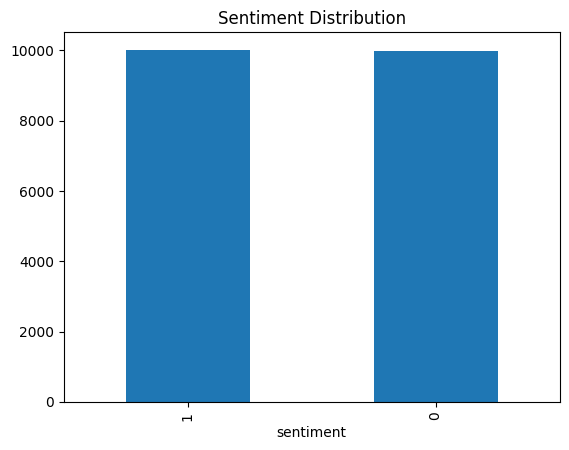

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ameer/Downloads/Food-Delivery-Pattern-Analysis--main/data/data/CLEAN_REVIEWS.csv")

# تنظيف الأعمدة
df.columns = df.columns.str.strip().str.lower()

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

In [7]:
top_restaurants = df.groupby("restaurant")["rating"].mean().sort_values(ascending=False).head(10)
print(top_restaurants)

restaurant
SpaghettiFactory    3.2025
KFC                 3.1925
Bazooka             3.1865
McDonalds           3.1765
Dominos             3.1740
CookDoor            3.1700
PizzaHut            3.1485
Hardees             3.1410
Zooba               3.1180
TacoBell            3.1085
Name: rating, dtype: float64


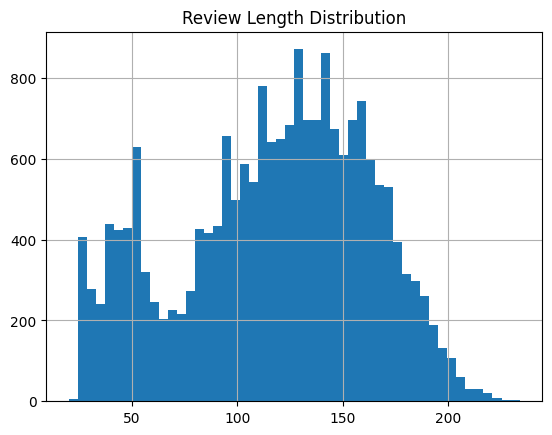

In [8]:
df["review_length"] = df["review"].apply(lambda x: len(str(x)))

df["review_length"].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

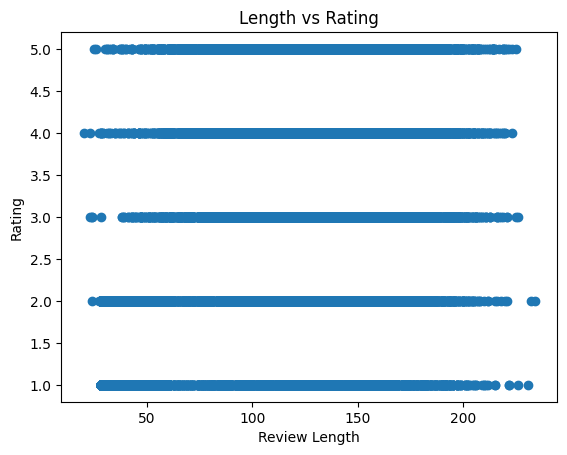

In [9]:
plt.scatter(df["review_length"], df["rating"])
plt.xlabel("Review Length")
plt.ylabel("Rating")
plt.title("Length vs Rating")
plt.show()